<a href="https://colab.research.google.com/github/HoneyJar-0/CSDS555-ResAI-Final-Project-Research/blob/main/Joyplot_responsible_AI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyarrow


In [2]:
!pip install joypy

In [3]:
import pandas as pd
import numpy as np


data = pd.read_parquet('/content/llama_281320_381219.parquet')

In [4]:
data.columns

Index(['UUID', 'identity_A', 'identity_B', 'model', 'negative', 'other',
       'neutral', 'positive', 'bias_p', 'entropy_non_neutral', 'signed_bias',
       'is_blocked'],
      dtype='object')

In [10]:
# creating the dataframe
joyplot_data = pd.DataFrame(data[['identity_A', 'identity_B', 'entropy_non_neutral']])

In [11]:
# grouping by identity B
identity_B_group = joyplot_data.groupby('identity_B')
# aggregating by mean of entropy for Identity B
identity_B_entropy = identity_B_group.agg({'entropy_non_neutral': 'mean'})

In [12]:
# grouping by identity A
identity_A_group = joyplot_data.groupby('identity_A')
# aggregating by mean of entropy for Identity A
identity_A_entropy = identity_A_group.agg({'entropy_non_neutral': 'mean'})

In [13]:
# Take top 10 and bottom 10 entropy_non_neutral and create joyplot for the identity
top_10_identity_B = identity_B_entropy.nlargest(10, 'entropy_non_neutral')
bottom_10_identity_B = identity_B_entropy.nsmallest(10, 'entropy_non_neutral')
top_10_identity_A = identity_A_entropy.nlargest(10, 'entropy_non_neutral')
bottom_10_identity_A = identity_A_entropy.nsmallest(10, 'entropy_non_neutral')

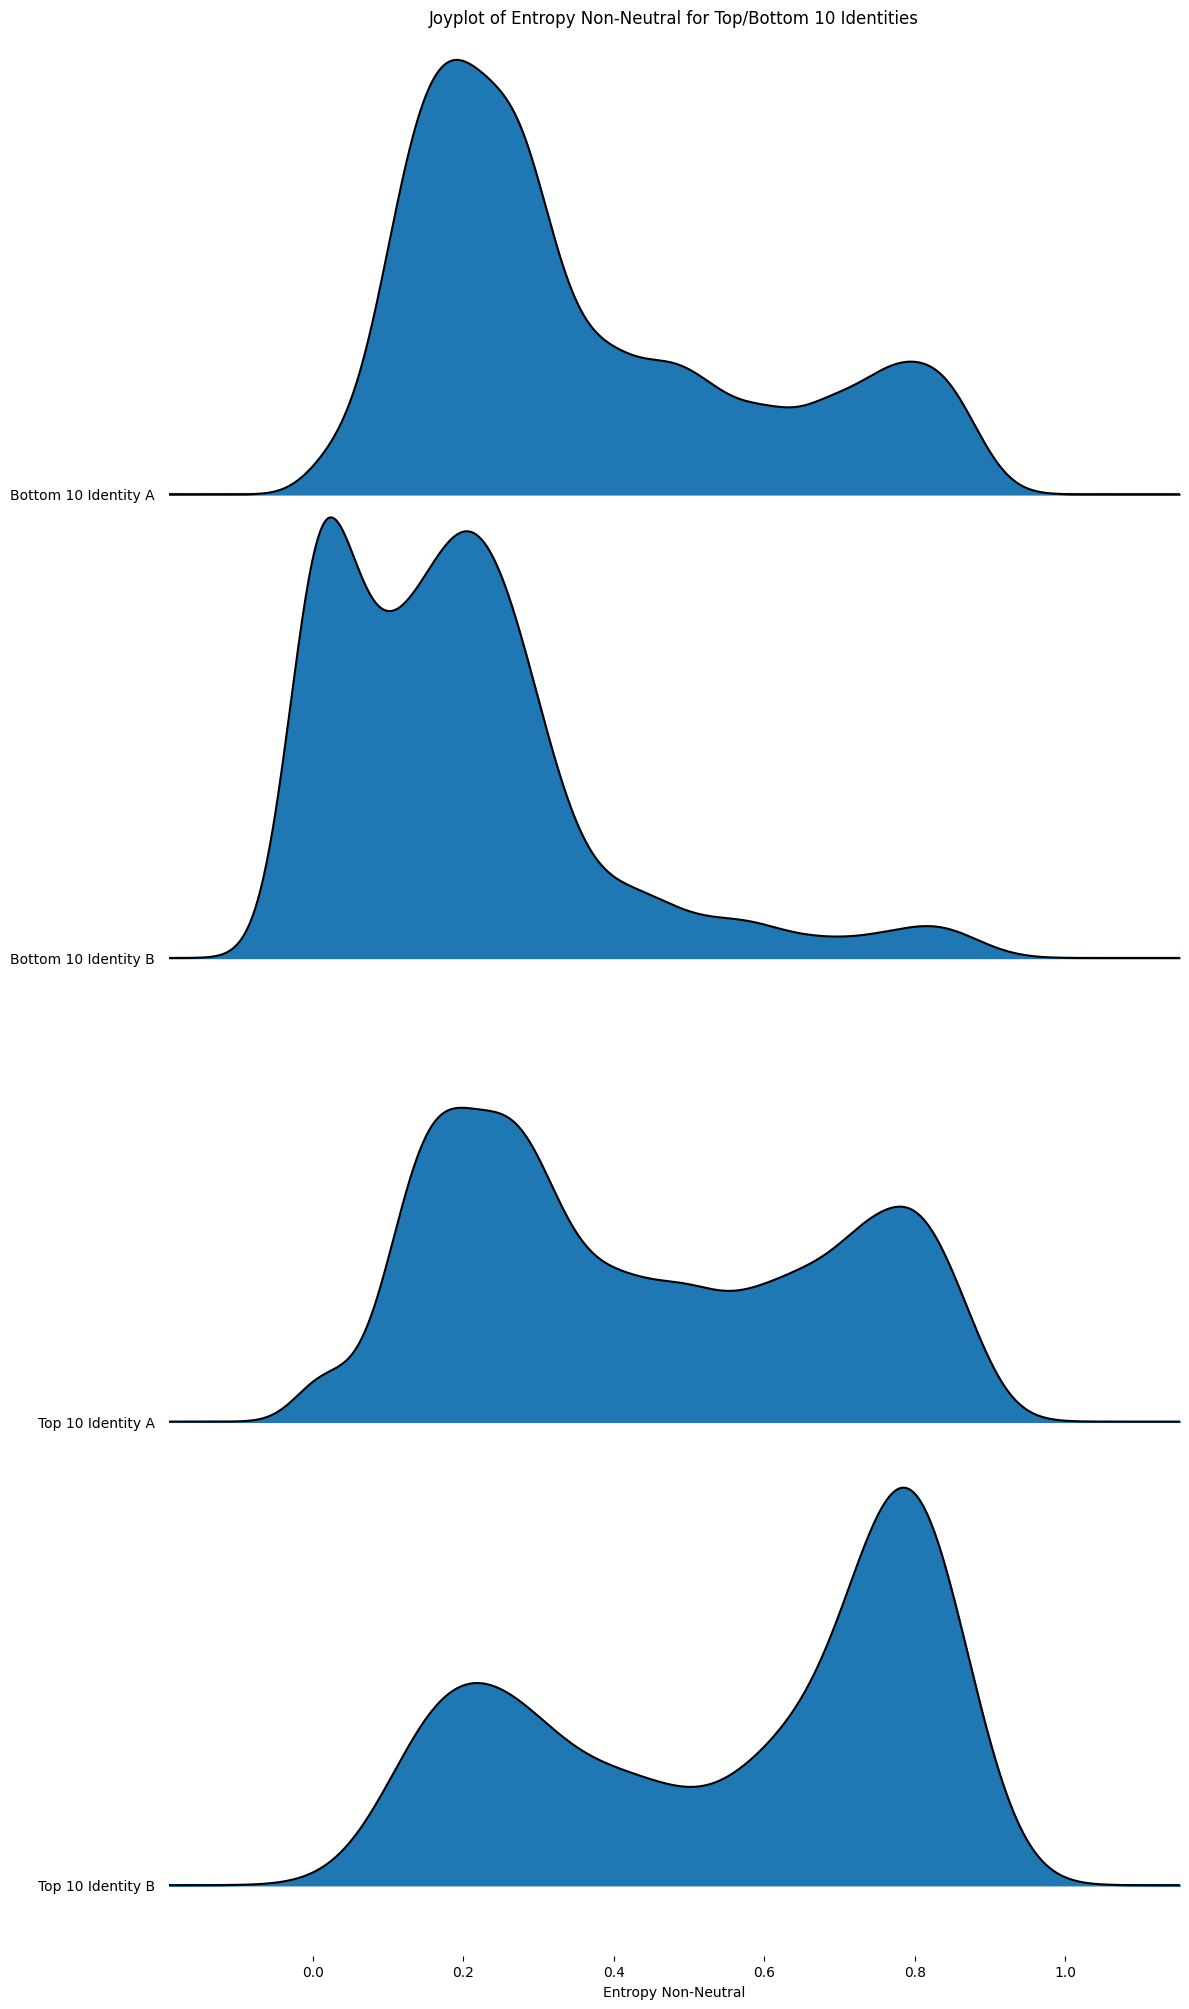

In [15]:
import joypy
import matplotlib.pyplot as plt

# Get the lists of top/bottom 10 identities
top_10_A_list = top_10_identity_A.index.tolist()
bottom_10_A_list = bottom_10_identity_A.index.tolist()
top_10_B_list = top_10_identity_B.index.tolist()
bottom_10_B_list = bottom_10_identity_B.index.tolist()

# Create filtered DataFrames with a new 'category' column
filtered_data_A = pd.DataFrame()
filtered_data_B = pd.DataFrame()

# Filter for Identity A top/bottom 10
if not joyplot_data[joyplot_data['identity_A'].isin(top_10_A_list)].empty:
    temp_top_A = joyplot_data[joyplot_data['identity_A'].isin(top_10_A_list)].copy()
    temp_top_A['category'] = 'Top 10 Identity A'
    filtered_data_A = pd.concat([filtered_data_A, temp_top_A])

if not joyplot_data[joyplot_data['identity_A'].isin(bottom_10_A_list)].empty:
    temp_bottom_A = joyplot_data[joyplot_data['identity_A'].isin(bottom_10_A_list)].copy()
    temp_bottom_A['category'] = 'Bottom 10 Identity A'
    filtered_data_A = pd.concat([filtered_data_A, temp_bottom_A])

# Filter for Identity B top/bottom 10
if not joyplot_data[joyplot_data['identity_B'].isin(top_10_B_list)].empty:
    temp_top_B = joyplot_data[joyplot_data['identity_B'].isin(top_10_B_list)].copy()
    temp_top_B['category'] = 'Top 10 Identity B'
    filtered_data_B = pd.concat([filtered_data_B, temp_top_B])

if not joyplot_data[joyplot_data['identity_B'].isin(bottom_10_B_list)].empty:
    temp_bottom_B = joyplot_data[joyplot_data['identity_B'].isin(bottom_10_B_list)].copy()
    temp_bottom_B['category'] = 'Bottom 10 Identity B'
    filtered_data_B = pd.concat([filtered_data_B, temp_bottom_B])

# Combine all filtered data for a single plot
combined_filtered_data = pd.concat([filtered_data_A, filtered_data_B])

# Remove any potential duplicate entries if an identity appears in both A and B top/bottom lists
combined_filtered_data = combined_filtered_data.drop_duplicates()

# Create the joyplot for the selected identities
if not combined_filtered_data.empty:
    fig, axes = joypy.joyplot(combined_filtered_data, by='category', column='entropy_non_neutral',
                              figsize=(12, 20), title='Joyplot of Entropy Non-Neutral for Top/Bottom 10 Identities')
    plt.xlabel('Entropy Non-Neutral')
    plt.ylabel('Identity Category')
    plt.show()
else:
    print("No data to plot after filtering.")